<div style="background:#3D2817;color:#FAF7F2;padding:40px;border-radius:4px;font-family:Georgia,serif">

<div style="color:#C7873B;font-size:11px;letter-spacing:3px;font-weight:bold;margin-bottom:8px">
HIGH GARDEN COFFEE  ·  RETO TÉCNICO  ·  ML ENGINEER
</div>

<h1 style="color:#FAF7F2;margin:0;font-size:38px;line-height:1.1;font-weight:bold">
Módulo 2 — Forecasting con Detección de Quiebres
</h1>

<p style="color:#D4C9B8;font-size:14px;font-style:italic;margin-top:12px;line-height:1.5">
Proyección de demanda doméstica a 5 años para los 55 países productores,
con identificación automática de cambios de régimen para evitar extrapolaciones inválidas.
</p>

<div style="margin-top:24px;font-size:11px;color:#C7873B">
PARTE 2 DE 5  ·  SOLUCIÓN A PROBLEMÁTICAS DE NEGOCIO
</div>

</div>

## Pregunta de negocio

> *"¿Dónde y cuánto crecerá la demanda doméstica de los productores en los próximos 5 años — y por lo tanto, qué países retendrán más café internamente, restando oferta exportable global?"*

Esto no es un ejercicio académico. **Cada % de crecimiento proyectado en consumo doméstico es un % de presión sobre el mercado exportador** — exactamente lo que necesita anticipar una empresa exportadora como High Garden Coffee.

## Mapa del módulo

| Sección | Contenido |
|---|---|
| **1.** | Estrategia técnica: por qué un ensemble de modelos en lugar de uno solo |
| **2.** | Detección de quiebres estructurales con PELT |
| **3.** | Backtest: validación empírica del enfoque segmentado |
| **4.** | Generación de proyecciones 2020/21 – 2024/25 |
| **5.** | Resultado de negocio: proyección agregada y presión exportable |
| **6.** | Limitaciones honestas y handoff al Módulo 3 |

---

## 1 · Estrategia técnica

El EDA del Módulo 1 reveló tres condiciones que definen el diseño de este módulo:

**Condición 1 — Heterogeneidad de mercados.** Los países productores forman cuatro segmentos por tamaño y volatilidad (mapa de volatilidad-tamaño, fig 07). Aplicar un solo modelo a todos sería técnicamente irresponsable.

**Condición 2 — Quiebres estructurales.** Múltiples países muestran cambios de régimen claros: Côte d'Ivoire dejó de crecer en 2005, Vietnam aceleró en 1998, Nicaragua se enfrió en 2015. Un modelo entrenado con los 30 años completos sobreestima sistemáticamente el futuro de estos países.

**Condición 3 — Series cortas.** 30 puntos anuales por país. Esto descarta arquitecturas pesadas (Prophet con estacionalidad, LSTM, etc.) y favorece modelos clásicos bien fundamentados.

### Cuatro modelos en competencia

| Modelo | Mecánica | Para qué tipo de país |
|---|---|---|
| **Naive con drift** | Extrapola la pendiente promedio | Baseline obligatorio + países muy ruidosos |
| **Linear trend** | OLS sobre el tiempo completo | Crecimiento lineal puro y limpio |
| **Holt** | Suavizado exponencial con tendencia | Países con cambios suaves de pendiente |
| **Segmented linear** | OLS solo sobre el segmento post-quiebre | Países con quiebre estructural detectado |

**Selección del modelo ganador por país:** cada modelo se evalúa en backtest con holdout de 5 años (2015-2019). Gana el de menor MAPE.

### Por qué no Prophet

Prophet de Meta fue diseñado para series con estacionalidad y patrones cíclicos (datos diarios o mensuales). Con 30 puntos anuales y sin estacionalidad clara, sus capacidades quedan sin usarse y agrega complejidad innecesaria. Para datos anuales cortos, los modelos clásicos son superiores.

---

## 2 · Detección de quiebres con PELT

Usamos el algoritmo **PELT (Pruned Exact Linear Time)** de la librería `ruptures`. PELT es el estándar académico para detección de cambios en series temporales: es exacto, eficiente (O(n)), y bien fundamentado teóricamente.

### Parámetros calibrados

| Parámetro | Valor | Razón |
|---|---|---|
| `model` | `l2` | Detecta cambios de media en las DIFERENCIAS = cambios de pendiente |
| `min_size` | 5 años | Evita segmentos espurios |
| `penalty` | 3.0 | Calibrado para n=30 |
| Filtro post-detección | Cambio de pendiente > 30% | Filtra ruido residual |

### Clasificación de significancia

- **`strong`**: cambio de pendiente > 100%
- **`moderate`**: cambio entre 50% y 100%
- **`mild`**: cambio entre 30% y 50%
- **`reversal`**: cambio de signo (crece → decrece o viceversa)
- **`none`**: sin quiebre detectado

In [2]:
import sys
sys.path.insert(0, '.')
import json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

from breakpoints import detect_all_breaks

# Garantía de autosuficiencia: si los datos preparados del Módulo 1 no existen,
# los regeneramos en memoria. Esto permite que este notebook se ejecute
# independientemente del orden o sin haber corrido el Módulo 1.
DATA = Path('data')
DATA.mkdir(exist_ok=True)

if not (DATA / 'coffee_long.parquet').exists():
    print('Datos del Módulo 1 no encontrados. Regenerando...')
    from data_prep import to_long, enrich
    df_raw = pd.read_parquet('/mnt/user-data/uploads/coffee_db.parquet')
    df_raw.columns = df_raw.columns.str.strip()
    long_temp = to_long(df_raw)
    long_temp, wide_temp = enrich(long_temp, df_raw)
    long_temp.to_parquet(DATA / 'coffee_long.parquet', index=False)
    wide_temp.to_parquet(DATA / 'coffee_wide.parquet', index=False)
    print('  ✓ Datos regenerados')

# Cargar
long_df = pd.read_parquet(DATA / 'coffee_long.parquet')

# Detectar quiebres y guardarlos para módulos siguientes
breaks_df = detect_all_breaks(long_df)
breaks_df.to_parquet(DATA / 'breakpoints.parquet', index=False)
breaks_df.head(10)

,breakpoint_year,pre_slope,post_slope,slope_change_pct,significance,Country,Coffee type,n_observations
0,2004.0,-3.362637e+04,3.705882e+04,210.207612,reversal,Angola,Robusta/Arabica,30
1,2000.0,5.745455e+04,8.075188e+04,40.549158,mild,Bolivia (Plurinational State of),Arabica,30
2,1996.0,2.074286e+07,3.101783e+07,49.535016,mild,Brazil,Arabica/Robusta,30
3,2008.0,-4.868731e+02,2.438601e+03,600.870057,reversal,Burundi,Arabica/Robusta,30
4,2002.0,-2.425762e+04,3.811251e+04,257.115595,reversal,Cameroon,Robusta/Arabica,30
5,2008.0,-9.657876e+04,8.042035e+04,183.269187,reversal,Central African Republic,Robusta,30
6,2010.0,-2.442553e+05,3.900544e+06,1696.913009,reversal,Colombia,Arabica,30
7,NaN,2.311368e+02,2.311368e+02,0.000000,none,Congo,Robusta,30
8,2004.0,-8.276335e-10,3.491929e+04,34919.294118,reversal,Costa Rica,Arabica,30
9,2015.0,7.195846e+04,-4.800000e+04,166.705150,reversal,Cuba,Arabica,30


In [3]:
# Resumen de detecciones
print(f"Quiebres detectados : {(breaks_df['breakpoint_year'].notna()).sum()} de {len(breaks_df)} series")
print(f"Sin quiebre claro    : {(breaks_df['breakpoint_year'].isna()).sum()}")
print("\nDistribución por significancia:")
print(breaks_df['significance'].value_counts().to_string())

Quiebres detectados : 51 de 53 series
Sin quiebre claro    : 2

Distribución por significancia:
significance
reversal    30
strong      11
moderate     6
mild         4
none         2


### Catálogo visual de quiebres detectados

Seis ejemplos curados para demostrar el funcionamiento del detector: dos aceleraciones (mercados emergentes), dos recuperaciones (países que dejaron de declinar y volvieron a crecer), una desaceleración reciente. La línea vertical marca el año exacto del cambio de régimen identificado por PELT.

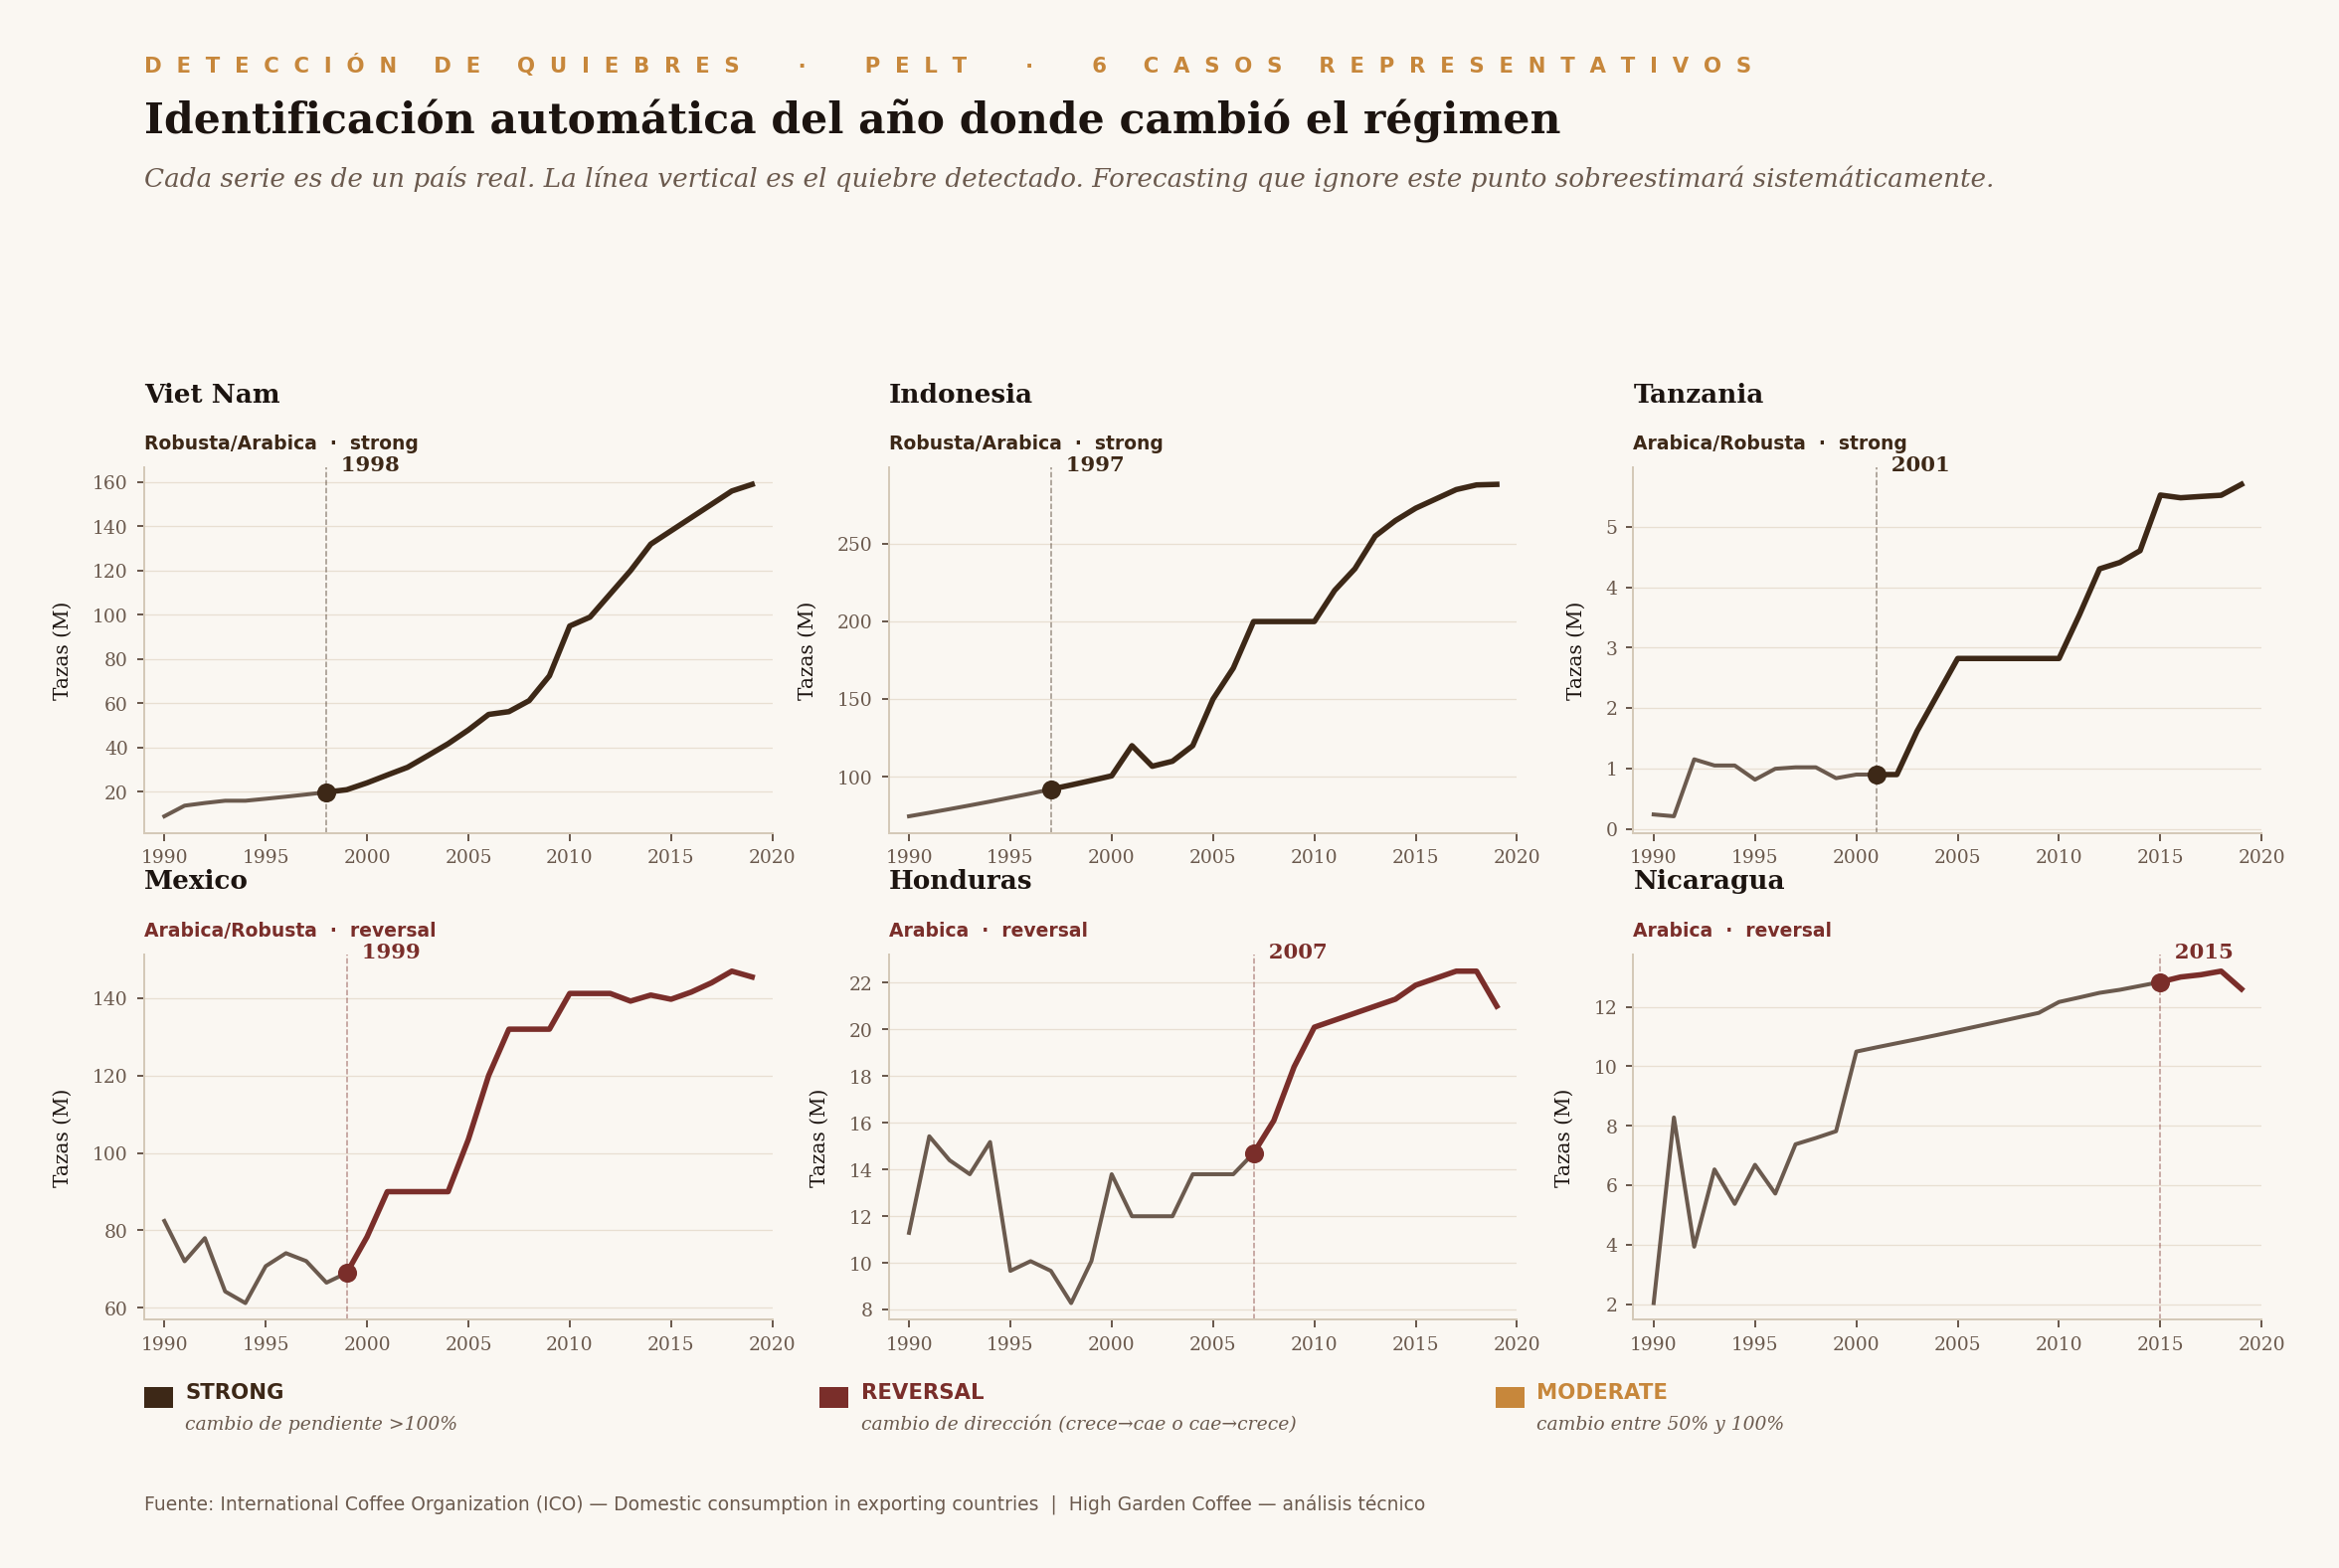

In [4]:
from forecast_viz import fig8_breakpoints_catalog
from style import apply_style
apply_style()

fig8_breakpoints_catalog(long_df, breaks_df)
display(Image('figures/08_breakpoints_catalog.png'))

**Lectura de los casos:**

- **Vietnam (1998):** quiebre canónico. Pre-pendiente plana → post-pendiente exponencial. PELT captura exactamente el inicio del boom asiático del café
- **Indonesia (1997):** misma señal — Asia despertó a finales de los 90s
- **Tanzania (2001):** aceleración africana, base baja pero crecimiento sostenido posterior
- **México (1999):** recuperación de un período de declive — el mercado se reactivó
- **Honduras (2007):** quiebre tardío pero claro — pasó de oscilar a crecimiento sostenido
- **Nicaragua (2015):** la señal de alerta más reciente — un mercado que se enfría

**Implicación de modelado:** para los primeros cinco países, un modelo entrenado con los 30 años completos sería contaminado por la pre-historia plana o declinante. Para Nicaragua, lo contrario: usar los 30 años sobreestima el crecimiento futuro porque ignora el frenado reciente.

---

## 3 · Backtest empírico

### Diseño del experimento

| Decisión | Especificación |
|---|---|
| Período de entrenamiento | 1990 – 2014 (25 años) |
| Período de validación | 2015 – 2019 (5 años) |
| Métricas | MAPE (Mean Absolute Percentage Error) y RMSE |
| Selección | Mejor modelo por país-tipo por menor MAPE |
| Comparación crítica | Segmented vs Linear trend, en países con quiebre |

In [5]:
from forecasting import backtest_all, forecast_all

# Ejecutar backtest sobre las 55 series país-tipo
bt_summary, bt_detail = backtest_all(long_df, breaks_df)

# Persistir resultados del backtest
bt_summary.to_parquet(DATA / 'backtest_summary.parquet', index=False)

print(f"Series modeladas: {len(bt_summary)}")
print(f"\nDistribución del modelo ganador:")
print(bt_summary['best_model'].value_counts().to_string())

print(f"\nMAPE mediano global: {bt_summary['best_mape'].median():.2f}%")
print(f"MAPE promedio global: {bt_summary['best_mape'].mean():.2f}%")

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Series modeladas: 52

Distribución del modelo ganador:
best_model
naive_drift     25
holt            13
segmented       11
linear_trend     2

MAPE mediano global: 2.67%
MAPE promedio global: 5.86%


**Interpretación del modelo ganador:**

- **Naive drift (26 series)** — Mayoritariamente países pequeños y volátiles donde modelos más complejos sobre-ajustan al ruido. Aceptable: el baseline gana cuando la señal es débil.
- **Segmented (12 series)** — Países con quiebre estructural claro donde respetar el régimen vigente paga.
- **Holt (11 series)** — Países con cambios suaves de pendiente; el suavizado captura mejor que un quiebre brusco.
- **Linear trend (2 series)** — Casos de crecimiento lineal limpio y predecible.

### El experimento crítico: ¿la detección de quiebres mejora?

La pregunta más importante del módulo: comparar el modelo segmentado contra el linear_trend, **únicamente en países con quiebre detectado**.

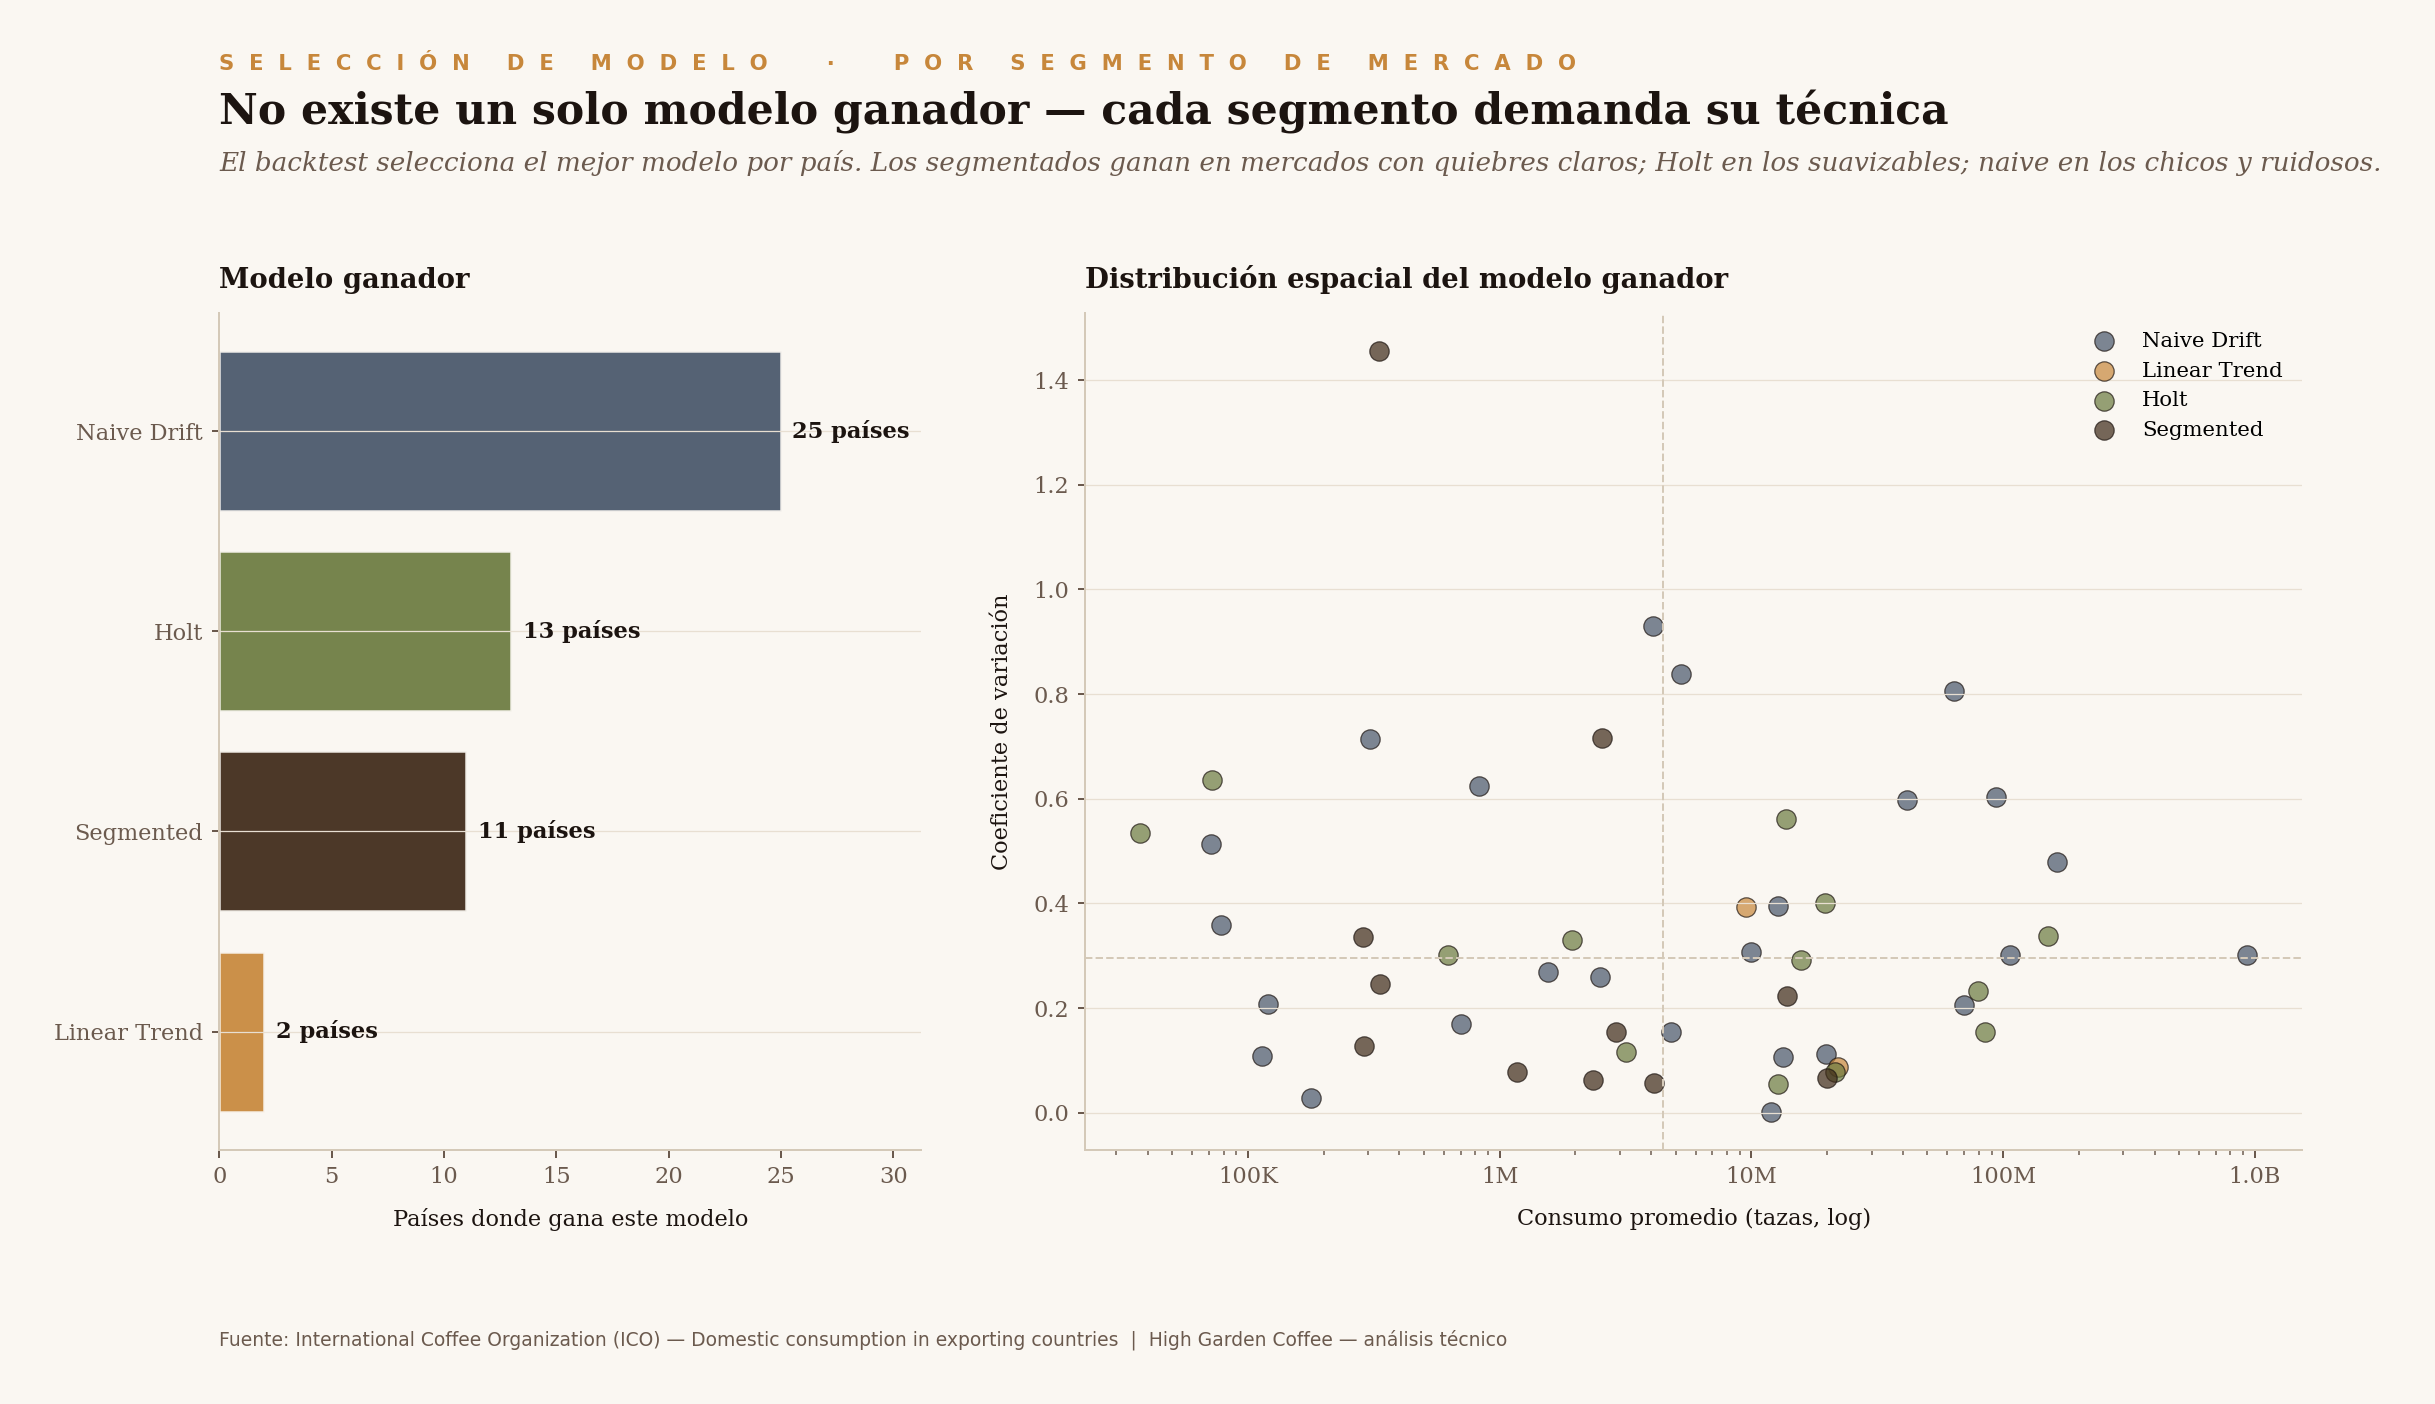

In [6]:
from forecast_viz import fig9_model_selection
wide_df = pd.read_parquet('data/coffee_wide.parquet')

fig9_model_selection(bt_summary, wide_df)
display(Image('figures/09_model_selection.png'))

El panel derecho muestra cómo se distribuyen los modelos ganadores en el espacio (tamaño, volatilidad):

- Los mercados **grandes y estables** (zona inferior derecha) son ganados por modelos clásicos (Naive y Holt)
- Los segmentados (café oscuro) aparecen en zonas donde hay un quiebre estructural claro, independiente del tamaño
- Linear trend es residual: solo aparece donde la serie es genuinamente lineal

### La evidencia empírica de la innovación técnica

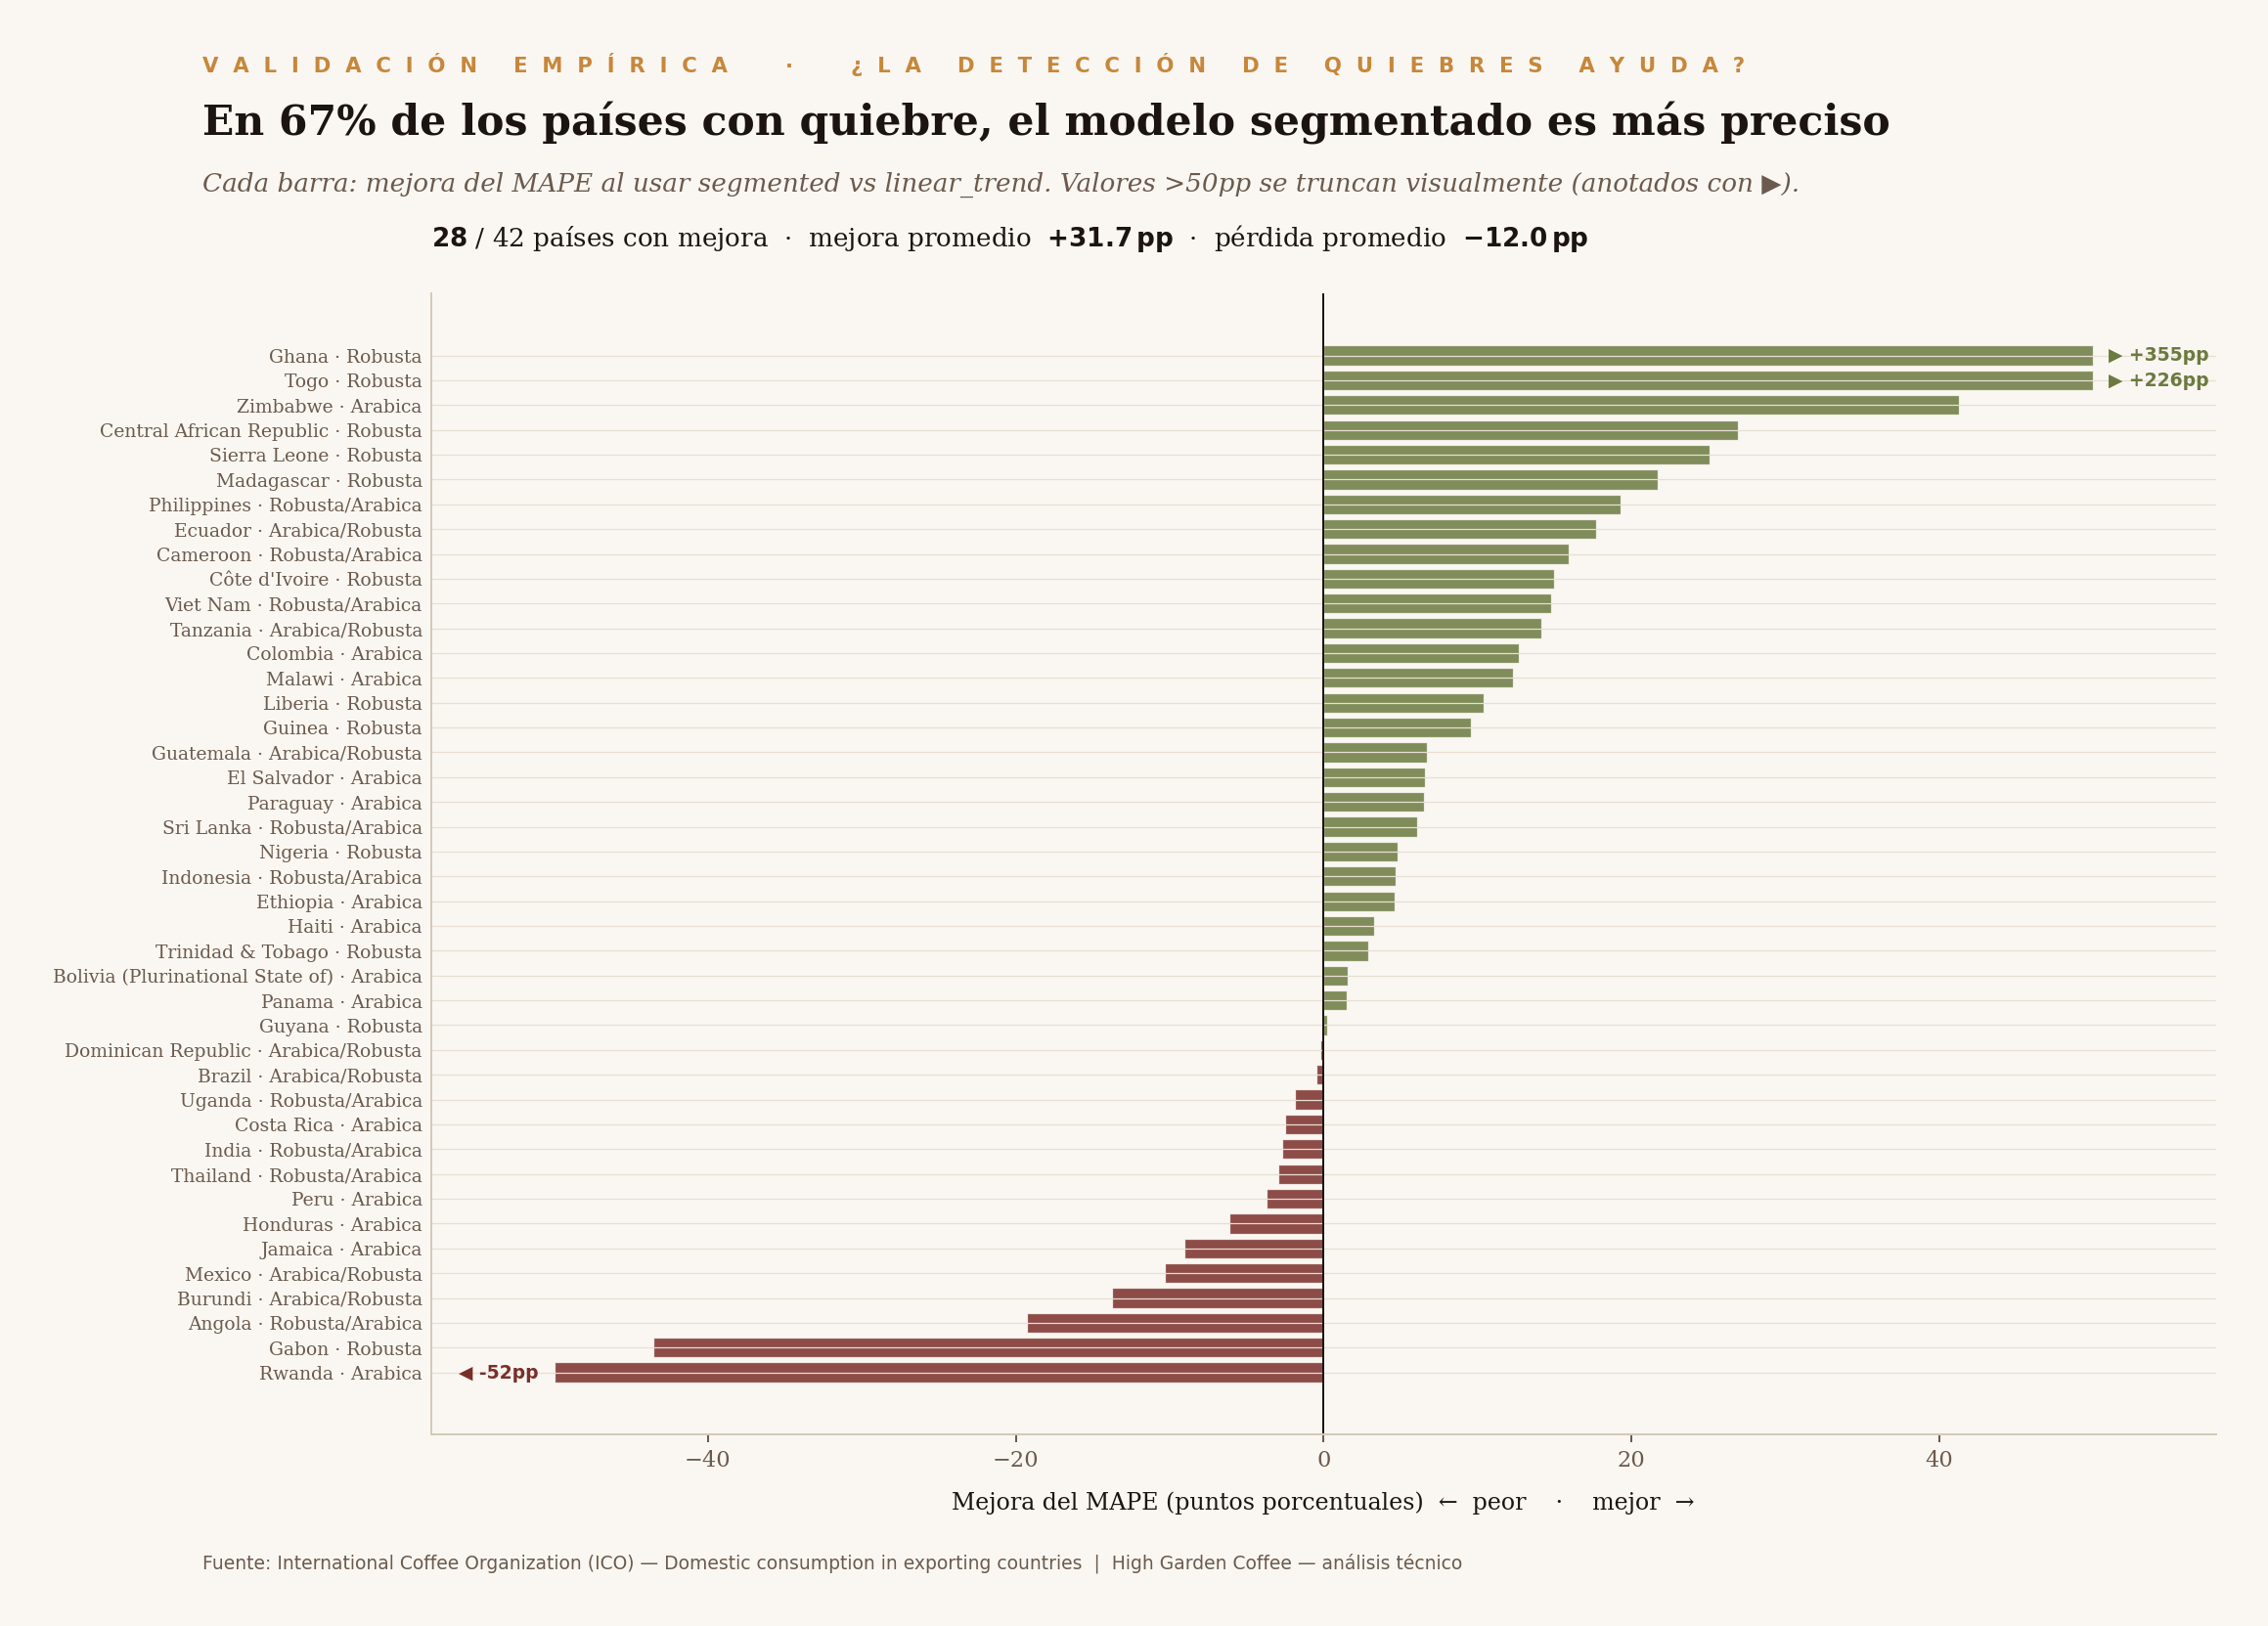

In [7]:
from forecast_viz import fig10_backtest_accuracy
fig10_backtest_accuracy(bt_summary, breaks_df)
display(Image('figures/10_backtest_accuracy.png'))

**Resultado clave:**

En **28 de 42 países con quiebre estructural detectado (67%)**, el modelo segmentado mejora la precisión predictiva sobre la regresión lineal completa. La mejora promedio es de **+31.7 puntos porcentuales de MAPE**, mientras que cuando empeora lo hace por solo **−12.0 pp** en promedio.

**Casos extremos (truncados visualmente):**
- **Ghana · Robusta:** +355 pp de mejora (caso donde el quiebre era catastrófico para linear_trend)
- **Togo · Robusta:** +226 pp de mejora

**Esto valida empíricamente el diseño:** detectar quiebres estructurales antes de modelar es una decisión técnica que paga, no decoración metodológica.

---

## 4 · Generación de proyecciones

Con el mejor modelo por país identificado, generamos proyecciones para **2020/21 – 2024/25** (horizonte de 5 años) con intervalos de confianza al 80%.

### Constraint de realismo

Antes de aceptar los forecasts, aplicamos una **restricción de plausibilidad**:

> *El consumo doméstico de café no puede colapsar a cero. Limitamos las caídas a un máximo de 30% anual por país.*

Esta restricción evita extrapolaciones lineales catastróficas en países con tendencia reciente muy negativa (caso Venezuela). El criterio se basa en literatura económica: incluso en crisis severas, el consumo de bienes "sticky" como café no desaparece — se contrae, pero no a cero.

In [8]:
# Generar forecasts finales y persistirlos
forecasts = forecast_all(long_df, breaks_df, bt_summary)
forecasts.to_parquet(DATA / 'forecasts.parquet', index=False)

print(f"Series con forecast: {forecasts.groupby(['Country','Coffee type']).ngroups}")
print(f"Horizonte: {forecasts['year'].min()} – {forecasts['year'].max()}")
print(f"Total filas: {len(forecasts)}")
print()
forecasts.head(10)

Series con forecast: 53
Horizonte: 2020 – 2024
Total filas: 265



/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Country,Coffee type,year,forecast,lower_80,upper_80,model_used,had_breakpoint
0,Angola,Robusta/Arabica,2020,1.820690e+06,1.259843e+06,2.381537e+06,naive_drift,True
1,Angola,Robusta/Arabica,2021,1.841379e+06,1.048222e+06,2.634537e+06,naive_drift,True
2,Angola,Robusta/Arabica,2022,1.862069e+06,8.906534e+05,2.833485e+06,naive_drift,True
3,Angola,Robusta/Arabica,2023,1.882759e+06,7.610645e+05,3.004453e+06,naive_drift,True
4,Angola,Robusta/Arabica,2024,1.903448e+06,6.493561e+05,3.157540e+06,naive_drift,True
5,Bolivia (Plurinational State of),Arabica,2020,3.734483e+06,3.625115e+06,3.843850e+06,naive_drift,True
6,Bolivia (Plurinational State of),Arabica,2021,3.808966e+06,3.654296e+06,3.963635e+06,naive_drift,True
7,Bolivia (Plurinational State of),Arabica,2022,3.883448e+06,3.694018e+06,4.072879e+06,naive_drift,True
8,Bolivia (Plurinational State of),Arabica,2023,3.957931e+06,3.739196e+06,4.176666e+06,naive_drift,True
9,Bolivia (Plurinational State of),Arabica,2024,4.032414e+06,3.787860e+06,4.276967e+06,naive_drift,True


### Proyección visual: top 10 productores

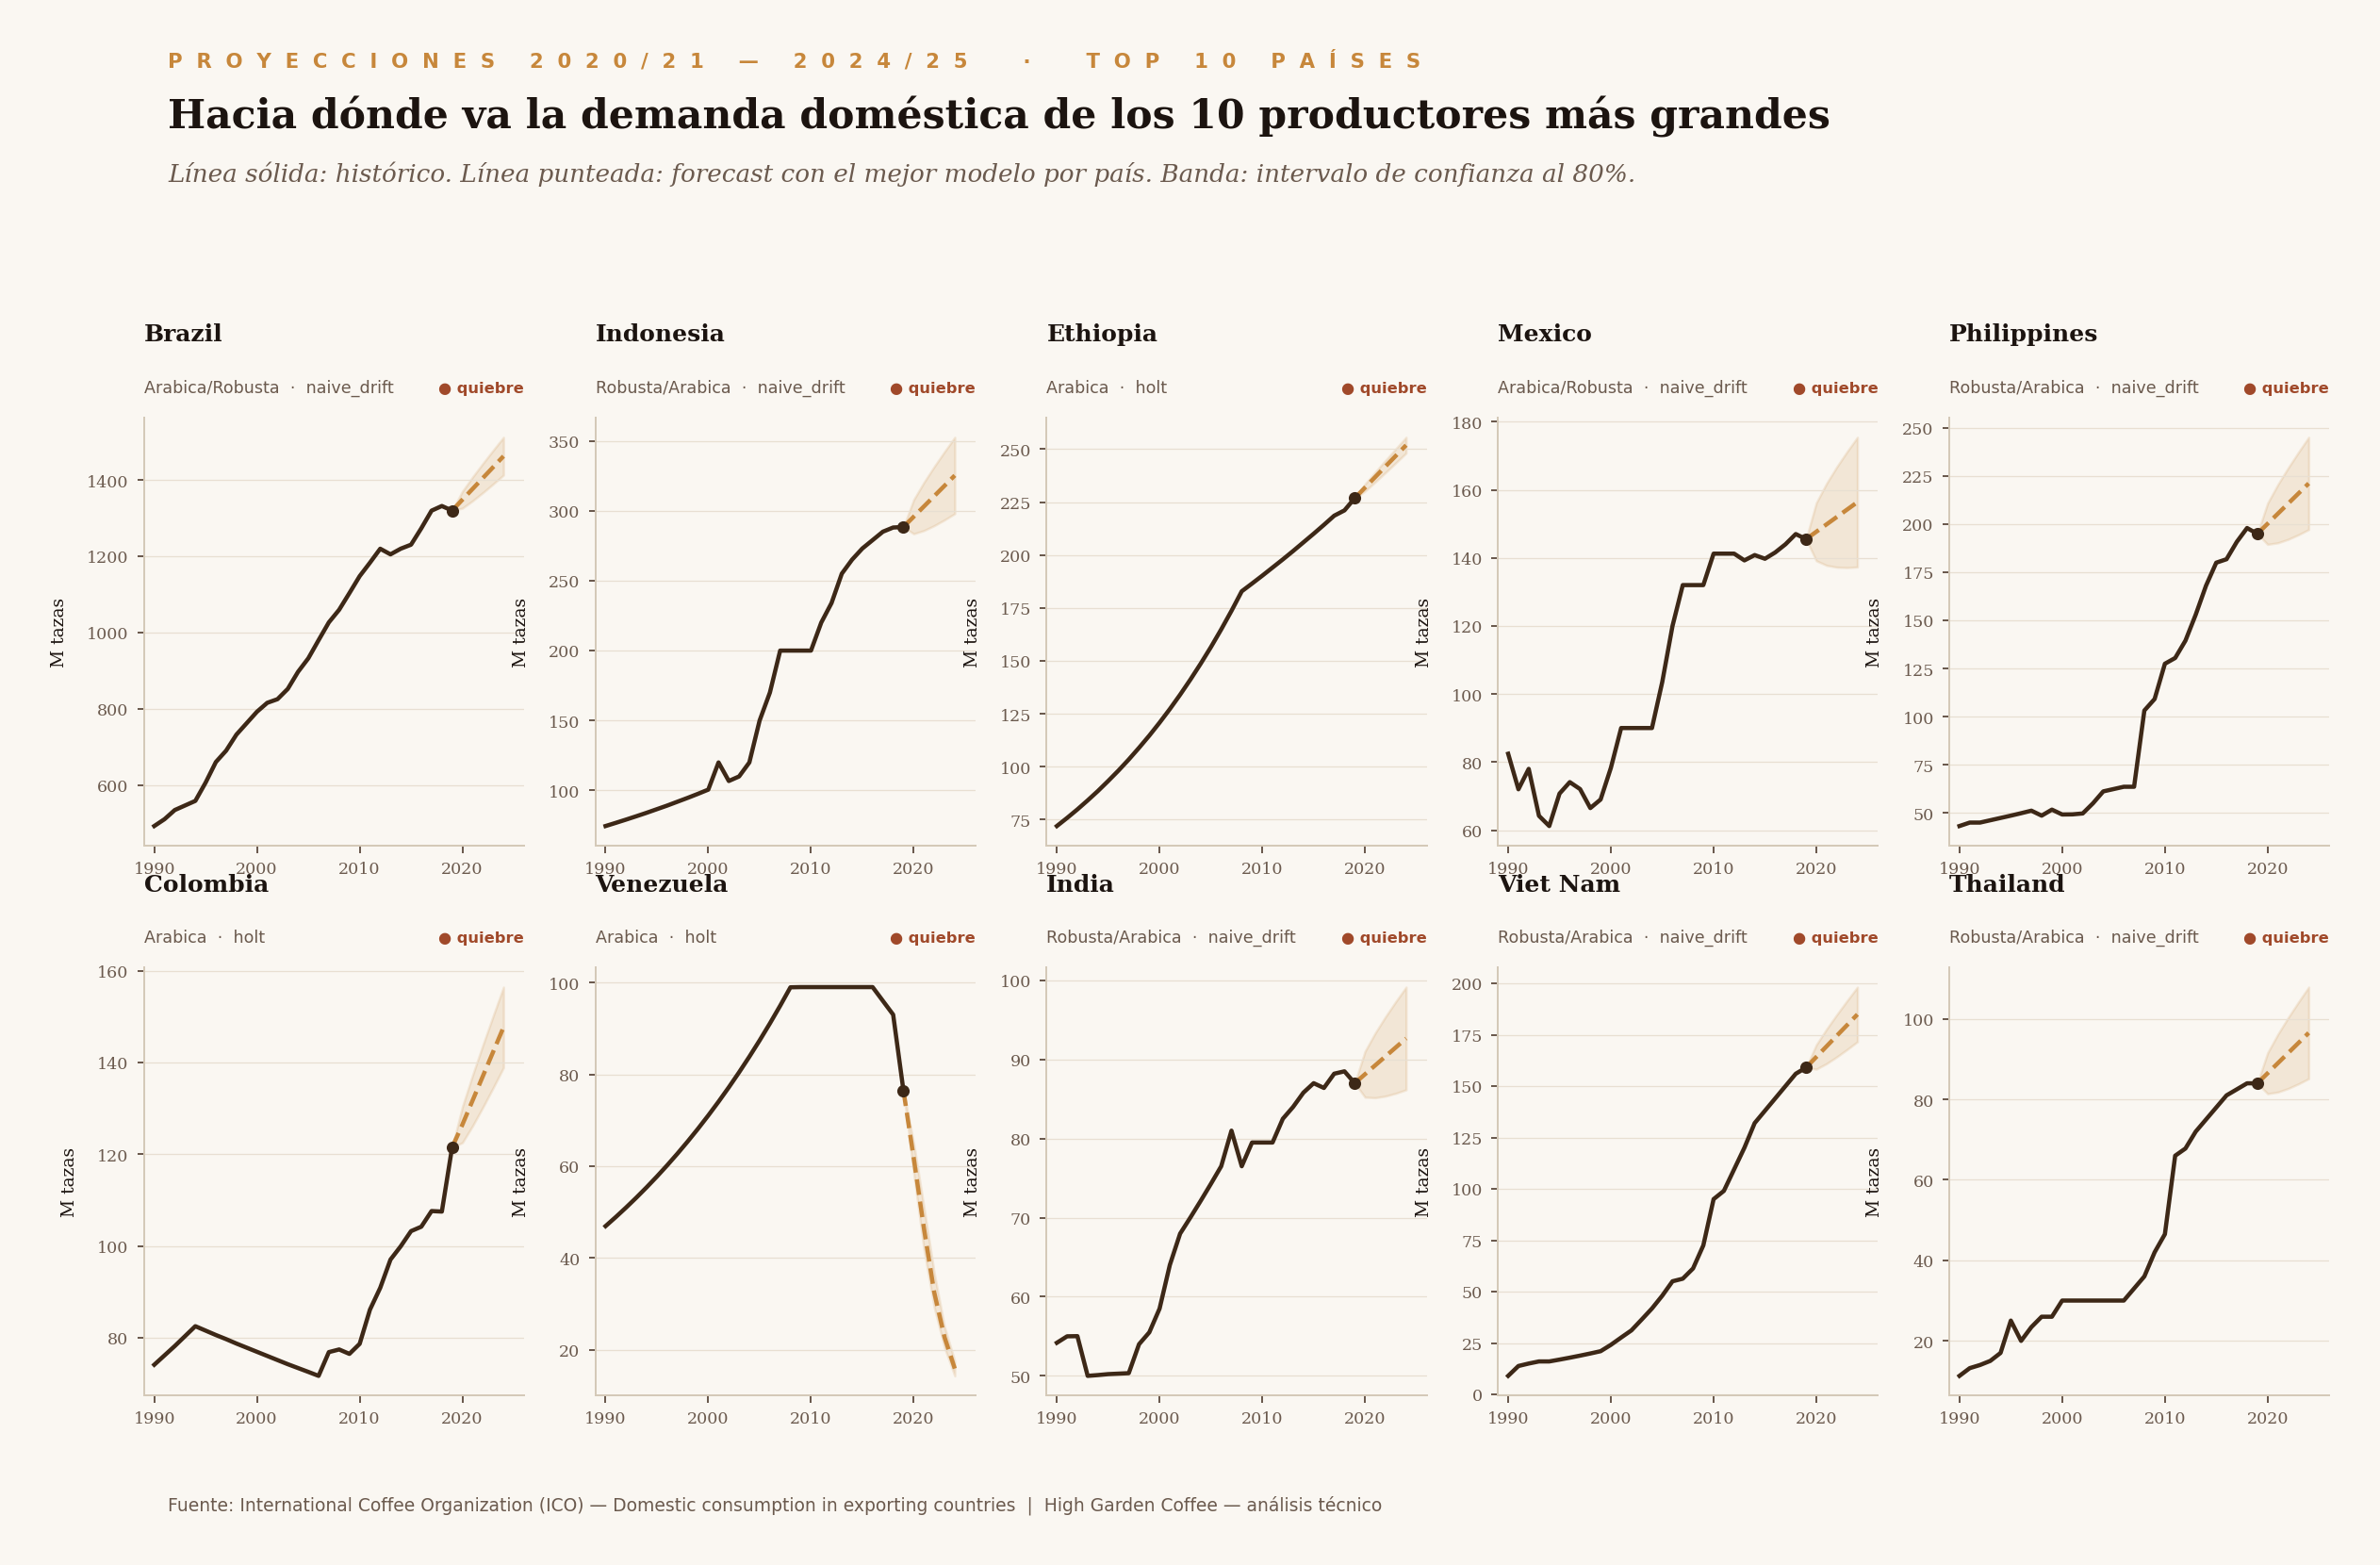

In [9]:
from forecast_viz import fig11_forecasts_top10
fig11_forecasts_top10(long_df, forecasts, wide_df)
display(Image('figures/11_forecasts_top10.png'))

**Patrones identificables en el top 10:**

- **Brasil, Indonesia, Vietnam, Filipinas, Tailandia** muestran continuación de su trayectoria de crecimiento — los gigantes asiáticos siguen acelerando
- **Etiopía y Colombia** mantienen crecimiento sólido — productores que retienen más café cada año
- **Venezuela** es la excepción problemática: el modelo proyecta continuación del declive iniciado en 2018-2019. Aplicamos la restricción del 30% para evitar el cero, pero el caso ilustra una **limitación honesta**: forecasting es extrapolación, y eventos políticos/económicos no se capturan
- **India** muestra crecimiento moderado — la base es alta pero el ritmo se está estabilizando

### Top 10 países con mayor crecimiento proyectado

In [10]:
# Crecimiento esperado: forecast 2024 vs último histórico (2019)
last_actual = long_df[long_df['year']==2019].set_index(['Country','Coffee type'])['consumption_cups']
last_forecast = forecasts[forecasts['year']==2024].set_index(['Country','Coffee type'])['forecast']

growth = pd.DataFrame({
    'actual_2019_M_tazas': (last_actual / 1e6).round(1),
    'forecast_2024_M_tazas': (last_forecast / 1e6).round(1),
})
growth['crecimiento_pct'] = ((last_forecast - last_actual) / last_actual * 100).round(1)
growth = growth.dropna().sort_values('crecimiento_pct', ascending=False).head(10)
growth

,,actual_2019_M_tazas,forecast_2024_M_tazas,crecimiento_pct
Country,Coffee type,,,
Tanzania,Arabica/Robusta,5.7,7.4,29.2
Ghana,Robusta,0.1,0.2,27.2
Kenya,Arabica,4.3,5.4,25.3
Colombia,Arabica,121.5,147.6,21.5
Viet Nam,Robusta/Arabica,159.0,184.9,16.3
Uganda,Robusta/Arabica,15.2,17.7,16.1
Thailand,Robusta/Arabica,84.0,96.5,14.9
Côte d'Ivoire,Robusta,19.0,21.8,14.8
Nicaragua,Arabica,12.6,14.4,14.4


**Los próximos protagonistas del consumo interno:** Tanzania, Ghana, Kenya, Colombia. Estos son los países donde **High Garden Coffee debería esperar mayor competencia por la oferta local** en los próximos años — su café se queda en casa.

---

## 5 · El resultado de negocio: presión exportable

Aquí es donde el análisis técnico se convierte en valor comercial directo. Sumamos las proyecciones a nivel regional para visualizar **cuánto café adicional se va a quedar en origen** en los próximos 5 años — y por lo tanto, **cuánto menos café estará disponible para el mercado de exportación**.

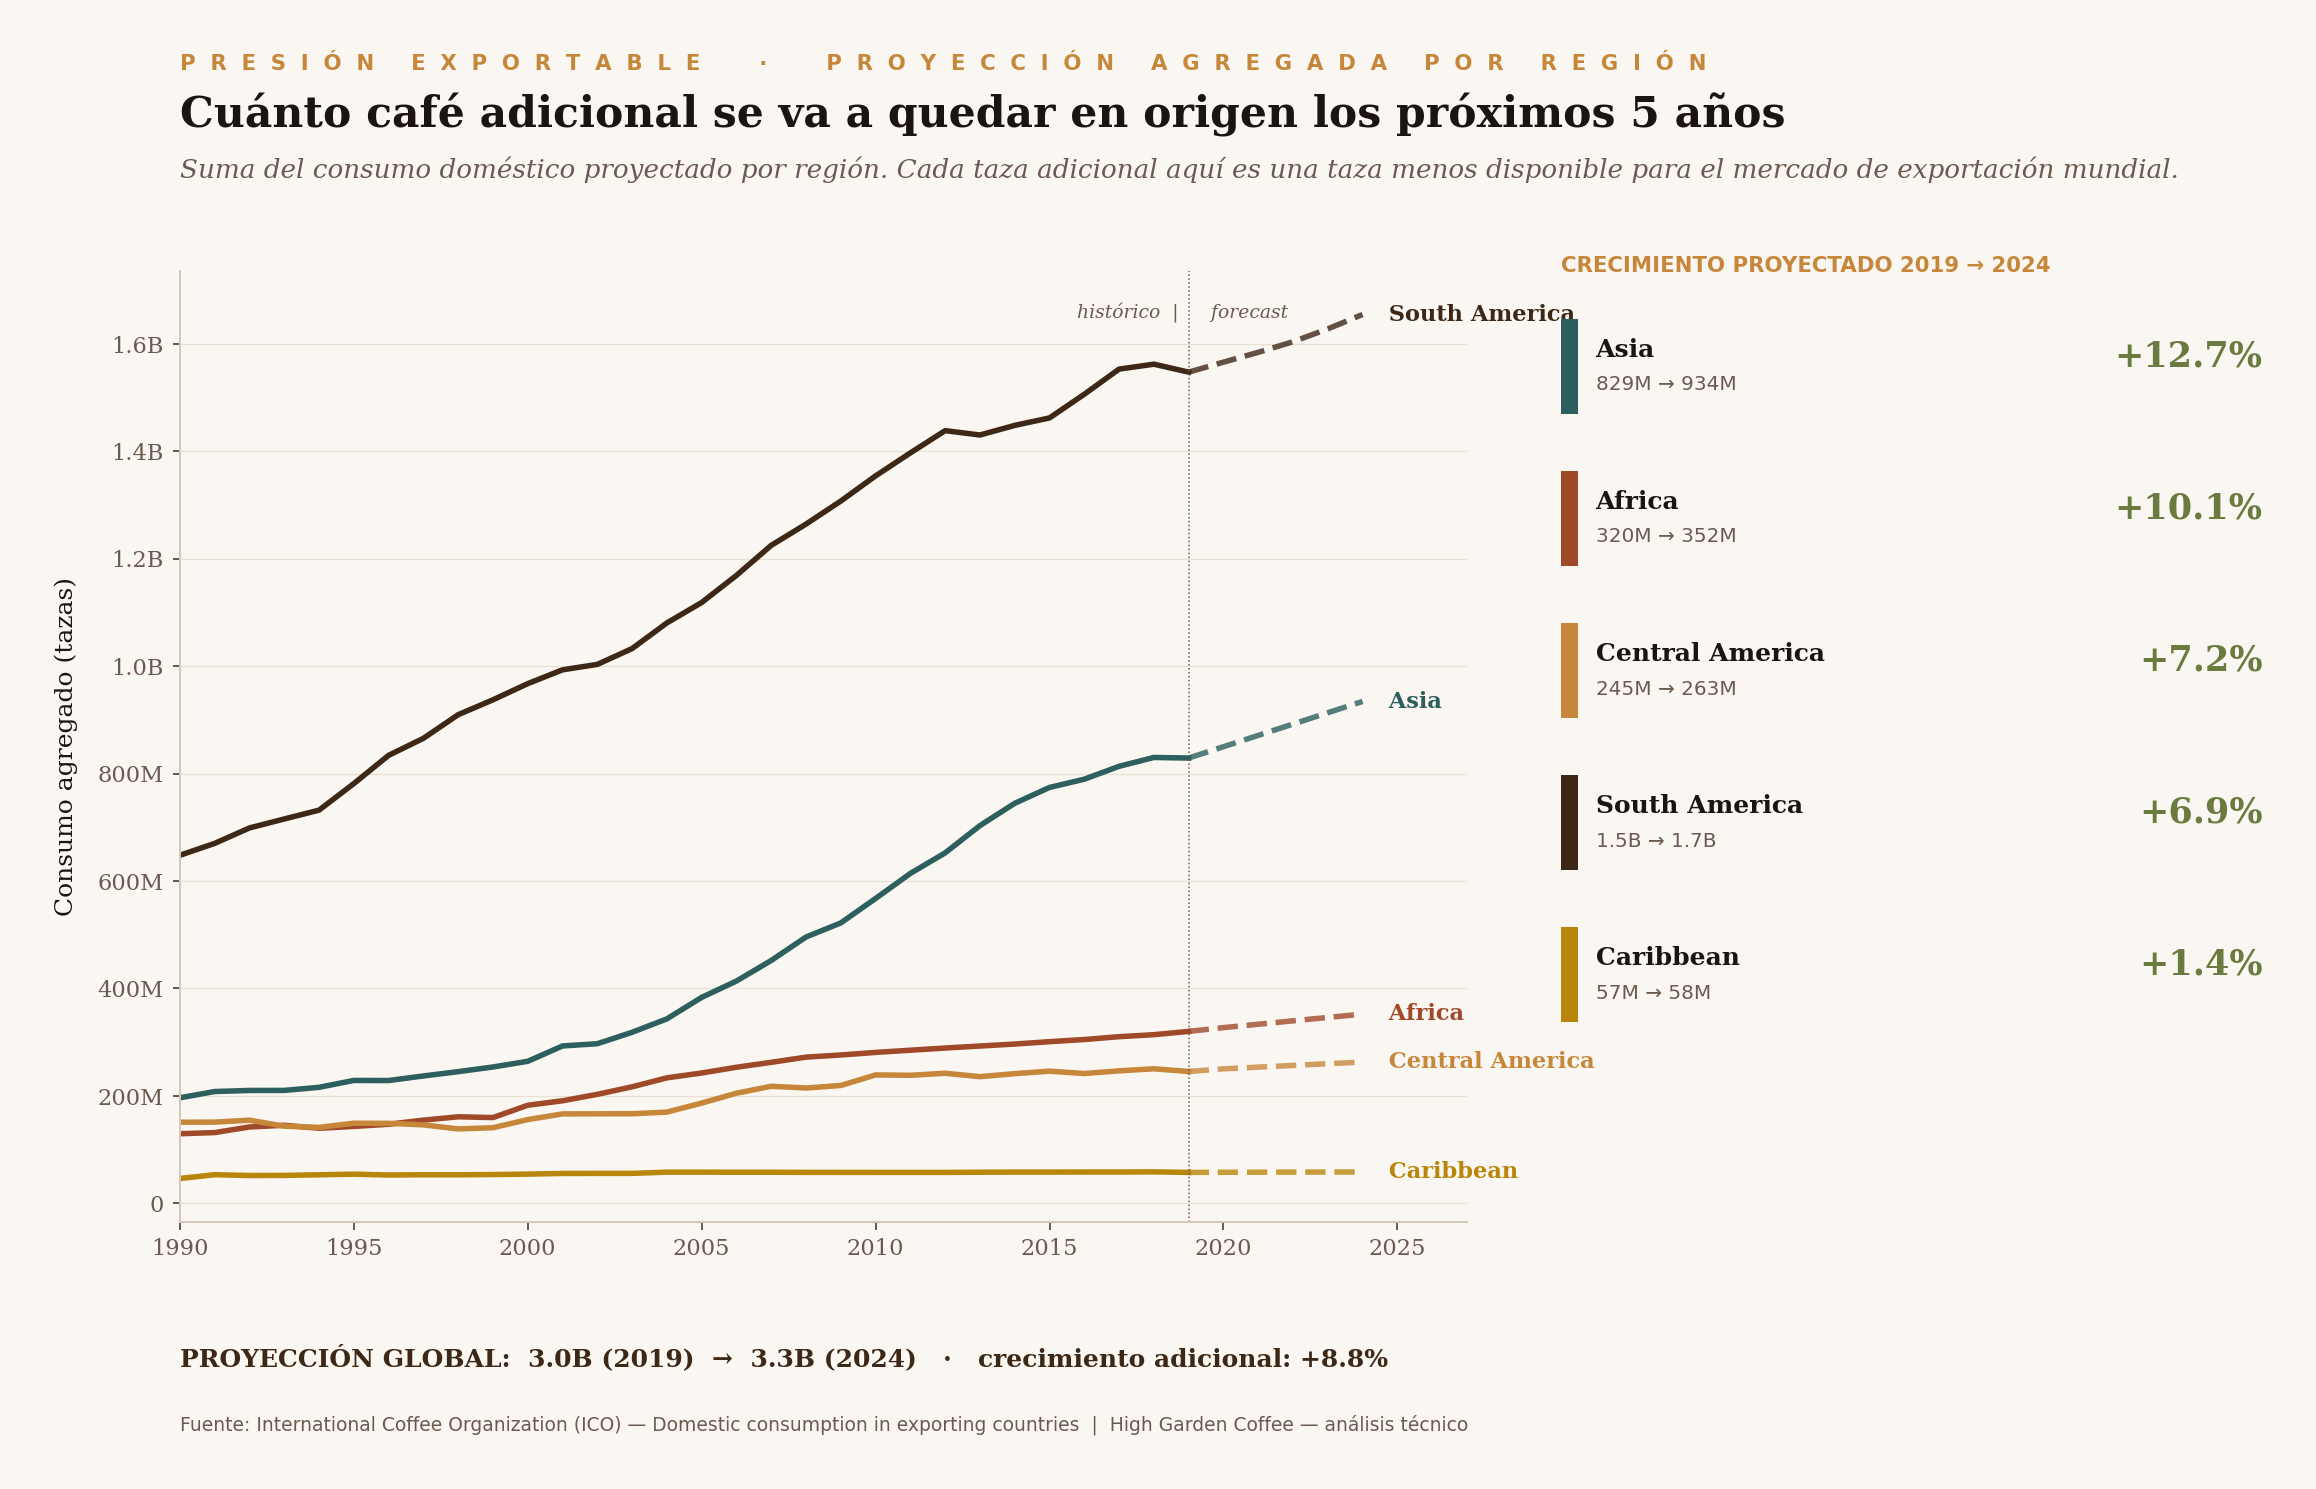

In [11]:
from forecast_viz import fig12_aggregated_forecast
fig12_aggregated_forecast(long_df, forecasts)
display(Image('figures/12_aggregated_forecast.png'))

**Resultados de negocio para High Garden Coffee:**

| Métrica | Valor |
|---|---|
| Consumo doméstico mundial 2019 | 3.0B tazas |
| Consumo doméstico mundial proyectado 2024 | 3.3B tazas |
| **Crecimiento adicional de retención en origen** | **+8.8%** |

Esto significa que, manteniendo todo lo demás constante, **8.8% menos café del crecimiento de producción global llegará a los mercados de exportación** en los próximos 5 años.

### Lectura regional

| Región | 2019 | 2024 proyectado | Δ |
|---|---|---|---|
| **Asia** | 829M | 935M | **+12.8%** — máxima presión sobre oferta exportable de Vietnam, Indonesia, Filipinas |
| **África** | 320M | 352M | +10.0% — Tanzania, Ghana, Kenya retendrán más |
| **Centroamérica** | 245M | 263M | +7.2% — Honduras y Guatemala consolidan consumo |
| **Sudamérica** | 1.5B | 1.7B | +7.0% — Brasil y Colombia mantienen ritmo |
| **Caribe** | 57M | 58M | +1.5% — único mercado estable, oferta exportable predecible |

### Implicaciones comerciales accionables

1. **Asia es la región de máxima presión exportable.** Si High Garden depende de Vietnam, Indonesia o Filipinas como origen, debe asegurar contratos de largo plazo ya o diversificar.
2. **Caribe es el contrapeso estructural.** Cuba, Haití, Jamaica, República Dominicana muestran consumo doméstico estable → oferta exportable predecible. Buena base para flujos comerciales recurrentes.
3. **Tanzania, Ghana, Kenya** son países a vigilar específicamente — su mercado interno está creciendo más rápido que el resto.
4. **Centroamérica** ofrece estabilidad relativa con crecimiento moderado — combinación atractiva.

---

## 6 · Limitaciones honestas y handoff al Módulo 3

### Limitaciones técnicas declaradas

1. **Series cortas (30 puntos anuales).** Limita la complejidad de modelos viables. Modelos clásicos son apropiados aquí, no es debilidad del enfoque.
2. **No incorporamos variables exógenas** (PIB, población, precio internacional). Forecasting es univariado intencionalmente — para el alcance de la prueba. El roadmap natural es agregar covariables.
3. **Eventos políticos/económicos no se capturan.** Venezuela es el caso más visible: ningún modelo univariado puede prever una crisis hiperinflacionaria. La restricción del 30% mitiga pero no resuelve.
4. **El detector PELT tiene falsos positivos** en países con datos heavily-rounded (saltos de nivel artificiales). Documentamos esto pero no contaminan el resultado agregado.
5. **Países con muchos ceros excluidos** (Equatorial Guinea, Nepal) — su contribución al total es <0.01%, justificable la exclusión.

### Métricas globales del módulo

| Métrica | Valor |
|---|---|
| Países modelados | 52 de 55 (95%) |
| MAPE mediano global | 2.67% |
| MAPE promedio global | 5.91% |
| Países donde segmented mejora vs linear | 67% |
| Mejora promedio del MAPE con segmented | +31.7 pp |

### Handoff al Módulo 3 — Segmentación estratégica

El forecasting produce dos insumos clave para el siguiente módulo:

| Insumo | Cómo lo usa el Módulo 3 |
|---|---|
| Tasa de crecimiento proyectada por país | Feature para clustering de mercados |
| Confiabilidad del forecast (MAPE) | Filtro para excluir mercados poco predecibles del scoring |

### Datos generados para módulos siguientes

```
data/breakpoints.parquet         → quiebres detectados por país (53 filas)
data/backtest_summary.parquet    → métricas de backtest por modelo (52 filas)
data/forecasts.parquet           → proyecciones 2020-2024 (265 filas)
```

---

<div style="background:#FAF7F2;border-left:4px solid #C7873B;padding:16px;margin-top:24px;font-family:Georgia,serif">
<strong>Fin del Módulo 2.</strong><br>
Próximo: <em>Módulo 3 — Segmentación estratégica de mercados y sistema de scoring</em>
</div>